In [1]:
# Imports
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from src.audio import extract_mfcc_features
from src.models import VAE, vae_loss
from src.evaluation import evaluation_easy
from src.visualisation import plot_training_loss, plot_tsne

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs('results_easy/plots', exist_ok=True)

In [2]:
TSV_PATH = 'data/sampled.tsv'
AUDIO_DIR = 'data/songs'

X, genres, languages = extract_mfcc_features(TSV_PATH, AUDIO_DIR)

# Normalise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to tensor
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

  0%|          | 0/1000 [00:00<?, ?it/s]/home/tanzim/miniconda3/envs/cse715-project/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 1000/1000 [01:45<00:00,  9.49it/s]


In [3]:
LATENT_DIM = 16
EPOCHS = 80

# Construct model
model = VAE(input_dim=X.shape[1], latent_dim=LATENT_DIM).to(device)
# Use Adam optimiser with learning rate = 1e-3
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)

# Create dataloader
dataset = torch.utils.data.TensorDataset(X_tensor)
loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

loss_history = []

# Train model
for epoch in range(EPOCHS):
    total_loss = 0
    model.train()

    for (x,) in loader:
        x = x.to(device)

        optimiser.zero_grad()
        recon, mu, logvar = model(x)
        loss = vae_loss(recon, x, mu, logvar)

        loss.backward()
        optimiser.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    loss_history.append(avg_loss)

    print(f'Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}')

# Save model and loss history
torch.save(model.state_dict(), 'results_easy/vae.pth')
np.save('results_easy/loss_history.npy', loss_history)

Epoch 1/80, Loss: 1.0056
Epoch 2/80, Loss: 0.9355
Epoch 3/80, Loss: 0.8130
Epoch 4/80, Loss: 0.8004
Epoch 5/80, Loss: 0.7938
Epoch 6/80, Loss: 0.7803
Epoch 7/80, Loss: 0.7828
Epoch 8/80, Loss: 0.7779
Epoch 9/80, Loss: 0.7571
Epoch 10/80, Loss: 0.7453
Epoch 11/80, Loss: 0.7319
Epoch 12/80, Loss: 0.7099
Epoch 13/80, Loss: 0.7080
Epoch 14/80, Loss: 0.6961
Epoch 15/80, Loss: 0.6939
Epoch 16/80, Loss: 0.7090
Epoch 17/80, Loss: 0.7083
Epoch 18/80, Loss: 0.6892
Epoch 19/80, Loss: 0.6926
Epoch 20/80, Loss: 0.6860
Epoch 21/80, Loss: 0.7052
Epoch 22/80, Loss: 0.6972
Epoch 23/80, Loss: 0.6915
Epoch 24/80, Loss: 0.6852
Epoch 25/80, Loss: 0.6923
Epoch 26/80, Loss: 0.6883
Epoch 27/80, Loss: 0.6793
Epoch 28/80, Loss: 0.6864
Epoch 29/80, Loss: 0.6864
Epoch 30/80, Loss: 0.6794
Epoch 31/80, Loss: 0.6834
Epoch 32/80, Loss: 0.6782
Epoch 33/80, Loss: 0.6837
Epoch 34/80, Loss: 0.6805
Epoch 35/80, Loss: 0.6758
Epoch 36/80, Loss: 0.6672
Epoch 37/80, Loss: 0.6778
Epoch 38/80, Loss: 0.6695
Epoch 39/80, Loss: 0.

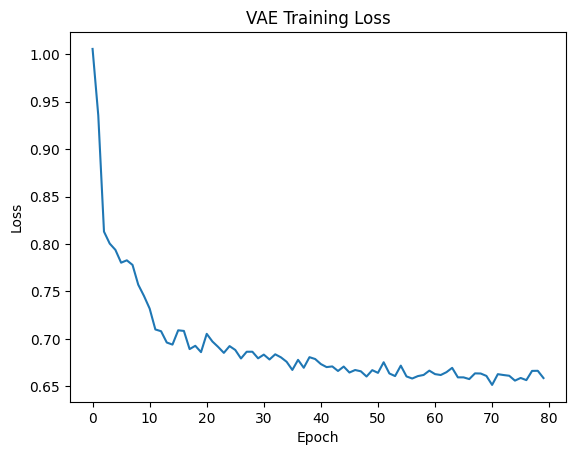

In [4]:
# Plot training loss and save figure
plot_training_loss(loss_history, 'results_easy/plots/loss_curve.svg')

In [5]:
# Get results from model for evaluation
model.eval()
with torch.no_grad():
    mu, _ = model.encode(X_tensor.to(device))
    Z = mu.cpu().numpy()

In [6]:
# Get PCA baseline for comparison (Note: PCA components = VAE latent dimensions for fair comparison)
pca = PCA(n_components=LATENT_DIM)
X_pca = pca.fit_transform(X_scaled)

In [7]:
results = []

for k, label_type, labels in [
    (2, 'language', languages),
    (6, 'genre', genres)
]:
    # Raw features
    _, _, sil_raw, ch_raw, ari_raw = evaluation_easy(X_scaled, labels, k)

    # PCA
    _, _, sil_pca, ch_pca, ari_pca = evaluation_easy(X_pca, labels, k)

    # VAE
    _, _, sil_vae, ch_vae, ari_vae = evaluation_easy(Z, labels, k)

    results.append([k, label_type, 'RAW', sil_raw, ch_raw, ari_raw])
    results.append([k, label_type, 'PCA', sil_pca, ch_pca, ari_pca])
    results.append([k, label_type, 'VAE', sil_vae, ch_vae, ari_vae])

    print(f'{label_type.upper()} (k={k})')
    print(f'RAW\tSil: {sil_raw:.4f}\tCH: {ch_raw:.2f}\tARI: {ari_raw:.4f}')
    print(f'PCA\tSil: {sil_pca:.4f}\tCH: {ch_pca:.2f}\tARI: {ari_pca:.4f}')
    print(f'VAE\tSil: {sil_vae:.4f}\tCH: {ch_vae:.2f}\tARI: {ari_vae:.4f}\n')

df_results = pd.DataFrame(results, columns=['k', 'label_type', 'method', 'silhouette', 'calinski_harabasz', 'ari'])
df_results.to_csv('results_easy/clustering_metrics.csv', index=False)

LANGUAGE (k=2)
RAW	Sil: 0.2880	CH: 358.85	ARI: -0.0007
PCA	Sil: 0.3251	CH: 454.41	ARI: -0.0007
VAE	Sil: 0.3490	CH: 510.73	ARI: 0.0002

GENRE (k=6)
RAW	Sil: 0.0766	CH: 136.06	ARI: 0.0630
PCA	Sil: 0.1070	CH: 180.81	ARI: 0.0716
VAE	Sil: 0.2878	CH: 406.16	ARI: 0.0600



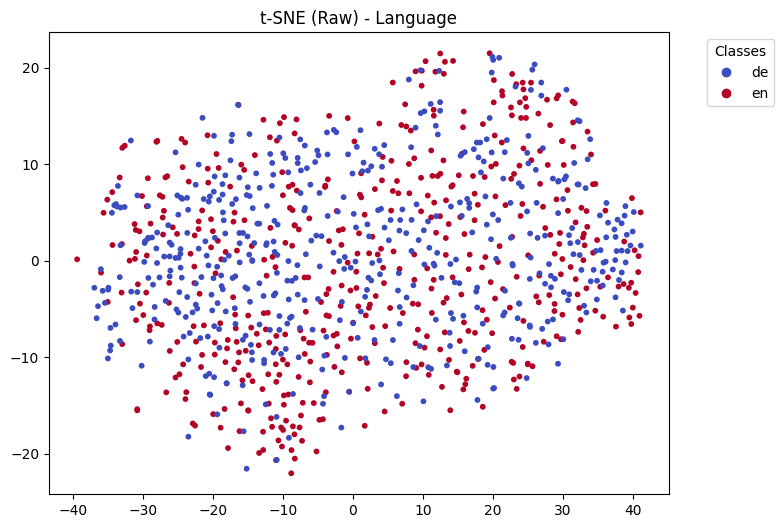

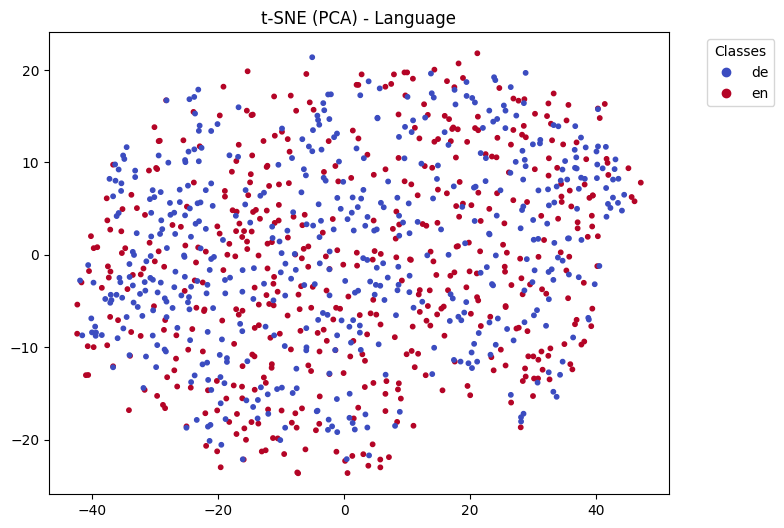

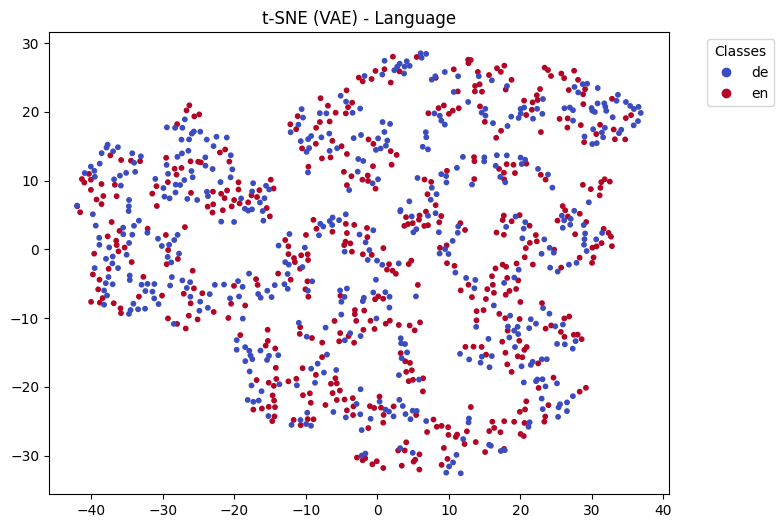

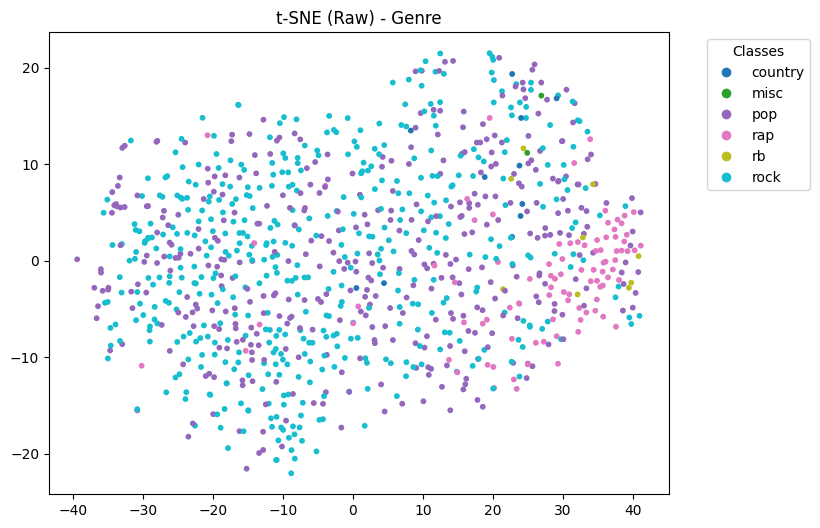

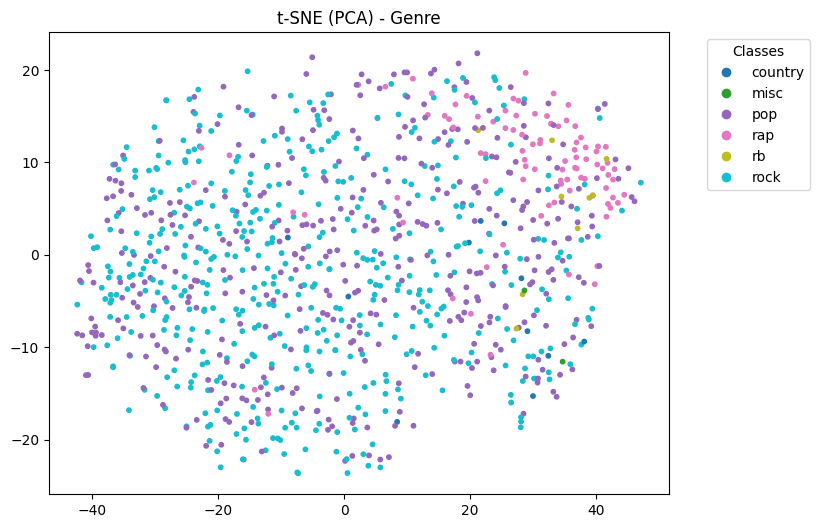

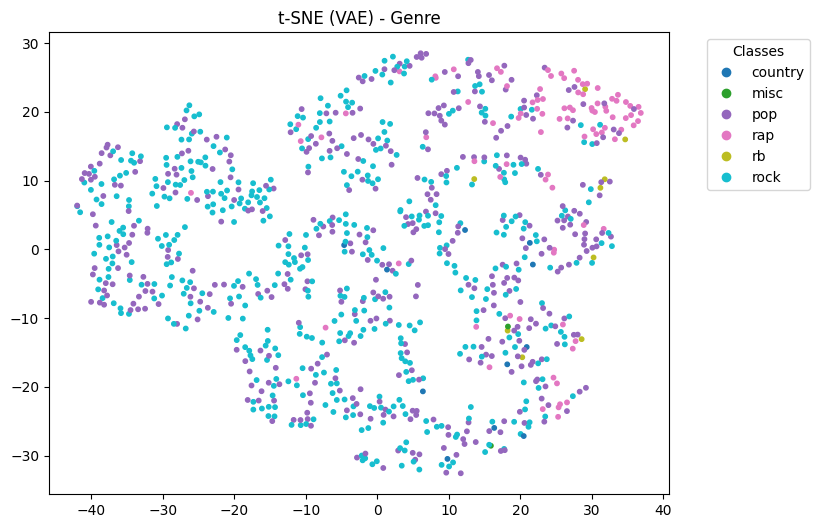

In [8]:
plot_tsne(X_scaled, languages, 't-SNE (Raw) - Language', 'results_easy/plots/tsne_language_raw.svg', cmap_name='coolwarm')
plot_tsne(X_pca, languages, 't-SNE (PCA) - Language', 'results_easy/plots/tsne_language_pca.svg', cmap_name='coolwarm')
plot_tsne(Z, languages, 't-SNE (VAE) - Language', 'results_easy/plots/tsne_language_vae.svg', cmap_name='coolwarm')
plot_tsne(X_scaled, genres, 't-SNE (Raw) - Genre', 'results_easy/plots/tsne_genre_raw.svg', cmap_name='tab10')
plot_tsne(X_pca, genres, 't-SNE (PCA) - Genre', 'results_easy/plots/tsne_genre_pca.svg', cmap_name='tab10')
plot_tsne(Z, genres, 't-SNE (VAE) - Genre', 'results_easy/plots/tsne_genre_vae.svg', cmap_name='tab10')